In [ ]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
# Ana ham veri klasörün:
BASE_RAW = PROJECT_ROOT / "night_vehicle_raw"
# Mesafe ve Exposure kök klasörleri
DIST_ROOT = BASE_RAW / "Mesafe - Exposure_50000_30fps"
EXPOSURE_ROOT = BASE_RAW / "Exposure_50000_30fps"

# Metadata klasörü (night_vehicle_raw içine koyuyoruz)
METADATA_DIR = BASE_RAW / "metadata"
METADATA_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_RAW:", BASE_RAW)
print("DIST_ROOT:", DIST_ROOT)
print("EXPOSURE_ROOT:", EXPOSURE_ROOT)
print("METADATA_DIR:", METADATA_DIR)


BASE_RAW: /Users/emreyigit/Desktop/sabanci/cs419/project/night_vehicle_raw
DIST_ROOT: /Users/emreyigit/Desktop/sabanci/cs419/project/night_vehicle_raw/Mesafe - Exposure_50000_30fps
EXPOSURE_ROOT: /Users/emreyigit/Desktop/sabanci/cs419/project/night_vehicle_raw/Exposure_50000_30fps
METADATA_DIR: /Users/emreyigit/Desktop/sabanci/cs419/project/night_vehicle_raw/metadata


In [ ]:
import re
from pathlib import Path
import pandas as pd
import cv2

VIDEO_EXTENSIONS = {".avi", ".mp4", ".mov", ".mkv"}

def get_video_info(video_path: Path):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        print(f"Uyarı: {video_path} açılamadı.")
        return None

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()

    duration_s = frame_count / fps if fps and fps > 0 else None

    return {
        "file_path": str(video_path),
        "file_name": video_path.name,
        "fps": fps,
        "frame_count": frame_count,
        "width": width,
        "height": height,
        "duration_s": duration_s
    }

def vehicle_id_from_folder(folder_name: str):
    """
    'Arac1' -> 1, 'Arac2' -> 2
    """
    name = folder_name.lower()
    m = re.search(r"arac\s*([0-9]+)", name)
    if m:
        return int(m.group(1))
    return None

def parse_light_mode_tr(name: str):
    """
    Dosya isminden Türkçe ışık modunu oku ve İngilizce label'a çevir.
    Örn:
      Pozisyon -> 'position'
      Fren     -> 'brake'
      Dortlu   -> 'hazard'
      kisa     -> 'low'
      uzun     -> 'high'
      DRL      -> 'drl'
    """
    n = name.lower()

    # DRL önce (drl içinde 'rl' falan karışmasın diye)
    if "drl" in n:
        return "drl"
    if "pozisyon" in n:
        return "position"
    if "fren" in n:
        return "brake"
    if "dortlu" in n or "dörtlü" in n:
        return "hazard"
    if "kisa" in n or "kısa" in n:
        return "low"
    if "uzun" in n:
        return "high"

    return None  # gerekirse sonradan elle doldurabilirsin


In [ ]:
def resize_by_scale(img, scale=1.0, interp=cv2.INTER_AREA):
    if scale is None or scale == 1.0:
        return img
    h, w = img.shape[:2]
    new_w = max(1, int(w * scale))
    new_h = max(1, int(h * scale))
    return cv2.resize(img, (new_w, new_h), interpolation=interp)

In [ ]:
distance_records = []

# DIST_ROOT içindeki Arac klasörlerini otomatik bul
for veh_dir in DIST_ROOT.iterdir():
    if not veh_dir.is_dir():
        continue

    veh_name = veh_dir.name            # 'Arac1' / 'Arac2'
    veh_id = vehicle_id_from_folder(veh_name)

    # Arac klasörü içindeki mesafe klasörleri (25m, 50m, 75m, 100m)
    for dist_dir in veh_dir.iterdir():
        if not dist_dir.is_dir():
            continue

        dist_name = dist_dir.name      # '25m' vb.

        # '25m' -> 25
        # klasör isimleri "25m" formatında olduğundan direkt int'e çeviriyoruz
        m = re.search(r"(\d+)", dist_name)
        if not m:
            print("Uyarı: Mesafe klasörü ismi beklenmedik format:", dist_dir)
            continue
        distance_m = int(m.group(1))

        # Her mesafe klasöründeki videolar
        for f in dist_dir.iterdir():
            if f.is_file() and f.suffix.lower() in VIDEO_EXTENSIONS:
                info = get_video_info(f)
                if info is None:
                    continue

                fname = info["file_name"]
                stem = fname.rsplit(".", 1)[0]

                # Benzersiz clip_id: Arac + mesafe + dosya ismi
                clip_id = f"{veh_name}_{dist_name}_{stem}"

                info["clip_id"]    = clip_id
                info["distance_m"] = distance_m
                info["vehicle_id"] = veh_id
                info["light_mode"] = parse_light_mode_tr(stem)

                distance_records.append(info)

distance_df = pd.DataFrame(distance_records)

cols = [
    "clip_id", "file_path", "file_name",
    "distance_m", "light_mode", "vehicle_id",
    "fps", "frame_count", "duration_s", "width", "height"
]
distance_df = distance_df[cols]

distance_csv_path = METADATA_DIR / "distance_clips.csv"
distance_df.to_csv(distance_csv_path, index=False)

distance_csv_path, distance_df.head()

(PosixPath('/Users/emreyigit/Desktop/sabanci/cs419/project/night_vehicle_raw/metadata/distance_clips.csv'),
                                              clip_id  \
 0  Arac2_50m_Basler acA2040-90umNIR (22821916)_20...   
 1  Arac2_50m_Basler acA2040-90umNIR (22821916)_20...   
 2  Arac2_50m_Basler acA2040-90umNIR (22821916)_20...   
 3  Arac2_50m_Basler acA2040-90umNIR (22821916)_20...   
 4  Arac2_100m_Basler acA2040-90umNIR (22821916)_2...   
 
                                            file_path  \
 0  /Users/emreyigit/Desktop/sabanci/cs419/project...   
 1  /Users/emreyigit/Desktop/sabanci/cs419/project...   
 2  /Users/emreyigit/Desktop/sabanci/cs419/project...   
 3  /Users/emreyigit/Desktop/sabanci/cs419/project...   
 4  /Users/emreyigit/Desktop/sabanci/cs419/project...   
 
                                            file_name  distance_m light_mode  \
 0  Basler acA2040-90umNIR (22821916)_20190513_212...          50   position   
 1  Basler acA2040-90umNIR (22821916)_201905

In [ ]:
def road_type_from_folder(folder_name: str):
    """
    Yol Tip1 / Yol Tip2 / Yol Tip3 klasörlerini
    kısa bir 'road_type' label'ına çevirir.
    """
    name = folder_name.lower().replace(" ", "")
    if "yoltip1" in name:
        return "3lane_median"
    if "yoltip2" in name:
        return "2lane_median"
    if "yoltip3" in name:
        return "2lane_bidirectional"
    return None

def road_desc_from_folder(folder_name: str):
    """
    Daha açıklayıcı, insan okunur açıklama.
    """
    name = folder_name.lower().replace(" ", "")
    if "yoltip1" in name:
        return "Arada refüj olan 3 şeritli otoban"
    if "yoltip2" in name:
        return "Arada refüj olan 2 şeritli otoban"
    if "yoltip3" in name:
        return "Arada refüj olmayan 2 şeritli çift yönlü yol"
    return ""


In [ ]:
exposure_records = []

# EXPOSURE_ROOT altındaki Yol Tip klasörlerini otomatik bul
for yol_dir in EXPOSURE_ROOT.iterdir():
    if not yol_dir.is_dir():
        continue

    folder_name = yol_dir.name   # 'Yol Tip1', 'Yol Tip2', ...
    road_type = road_type_from_folder(folder_name)
    road_desc = road_desc_from_folder(folder_name)

    print(f"Klasör: {folder_name} -> road_type={road_type}")

    # O yol tipindeki tüm videolar
    for f in yol_dir.iterdir():
        if f.is_file() and f.suffix.lower() in VIDEO_EXTENSIONS:
            info = get_video_info(f)
            if info is None:
                continue

            fname = info["file_name"]
            stem = fname.rsplit(".", 1)[0]

            # clip_id: YolTip + dosya adı birleşik (boşlukları kaldırıyoruz)
            clip_id = f"{folder_name.replace(' ', '')}_{stem}"

            info["clip_id"]   = clip_id
            info["road_type"] = road_type
            info["road_desc"] = road_desc
            info["notes"]     = ""   # buraya istersen sonradan 'wet', 'curve' vb. elle doldurabilirsin

            exposure_records.append(info)

exposure_df = pd.DataFrame(exposure_records)

cols = [
    "clip_id", "file_path", "file_name",
    "road_type", "road_desc", "notes",
    "fps", "frame_count", "duration_s", "width", "height"
]
exposure_df = exposure_df[cols]

exposure_csv_path = METADATA_DIR / "exposure_clips.csv"
exposure_df.to_csv(exposure_csv_path, index=False)

exposure_csv_path, exposure_df.head()


Klasör: Yol Tip1 -> road_type=3lane_median
Klasör: Yol Tip3 -> road_type=2lane_bidirectional
Klasör: Yol Tip2 -> road_type=2lane_median


(PosixPath('/Users/emreyigit/Desktop/sabanci/cs419/project/night_vehicle_raw/metadata/exposure_clips.csv'),
                                              clip_id  \
 0  YolTip1_Basler acA2040-90umNIR (22821916)_2019...   
 1  YolTip1_Basler acA2040-90umNIR (22821916)_2019...   
 2  YolTip1_Basler acA2040-90umNIR (22821916)_2019...   
 3  YolTip1_Basler acA2040-90umNIR (22821916)_2019...   
 4  YolTip1_Basler acA2040-90umNIR (22821916)_2019...   
 
                                            file_path  \
 0  /Users/emreyigit/Desktop/sabanci/cs419/project...   
 1  /Users/emreyigit/Desktop/sabanci/cs419/project...   
 2  /Users/emreyigit/Desktop/sabanci/cs419/project...   
 3  /Users/emreyigit/Desktop/sabanci/cs419/project...   
 4  /Users/emreyigit/Desktop/sabanci/cs419/project...   
 
                                            file_name     road_type  \
 0  Basler acA2040-90umNIR (22821916)_20190509_213...  3lane_median   
 1  Basler acA2040-90umNIR (22821916)_20190509_213...  3lane_m

In [ ]:
import pandas as pd
import cv2
# Metadata dosyalarını yükle
distance_df = pd.read_csv(METADATA_DIR / "distance_clips.csv")
exposure_df = pd.read_csv(METADATA_DIR / "exposure_clips.csv")

def get_row_by_clip_id(clip_id: str, source: str = "distance"):
    """
    clip_id ve source ('distance' / 'exposure') bilgisine göre
    ilgili metadata satırını döndürür.
    """
    if source == "distance":
        df = distance_df
    elif source == "exposure":
        df = exposure_df
    else:
        raise ValueError("source 'distance' veya 'exposure' olmalı.")

    rows = df[df["clip_id"] == clip_id]
    if rows.empty:
        raise ValueError(f"clip_id bulunamadı: {clip_id}")

    return rows.iloc[0]

def open_capture_for_clip(clip_id: str, source: str = "distance"):
    """
    Verilen clip_id için videoyu açar ve:
      - cap: cv2.VideoCapture nesnesi
      - meta: ilgili metadata satırı (fps, frame_count, vs. için)
    döndürür.
    """
    meta = get_row_by_clip_id(clip_id, source)
    video_path = Path(meta["file_path"])

    if not video_path.exists():
        raise FileNotFoundError(f"Video dosyası bulunamadı: {video_path}")

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise IOError(f"Video açılamadı: {video_path}")

    print(f"Video açıldı: {video_path}")
    return cap, meta

In [ ]:
# Distance veri setinden bir klip aç
cap, meta = open_capture_for_clip("Arac1_75m_Basler acA2040-90umNIR (22821916)_20190513_211341257_dortlu", source="distance")

# İşimiz bitince:
cap.release()


Video açıldı: /Users/emreyigit/Desktop/sabanci/cs419/project/night_vehicle_raw/Mesafe - Exposure_50000_30fps/Arac1/75m/Basler acA2040-90umNIR (22821916)_20190513_211341257_dortlu.mp4


In [ ]:
def iterate_frames_for_clip(clip_id: str, source: str = "distance", max_frames: int = None):
    """
    Verilen clip_id için videoyu açar ve frame'leri sırayla döner.
    Şimdilik sadece:
      - orig_frame_idx (0,1,2,...)
      - time_s (saniye cinsinden)
      - frame (henüz hiçbir preprocessing yapılmamış BGR görüntü)
    üretir.

    max_frames: None değilse, o kadar frame'den sonra durur (debug için).
    """
    # 1) Videoyu aç (1. adımda yazdığımız fonksiyon)
    cap, meta = open_capture_for_clip(clip_id, source=source)
    fps = meta["fps"]
    if fps is None or fps == 0:
        # fps metadata'da yoksa capture'dan da deneyebiliriz
        fps = cap.get(cv2.CAP_PROP_FPS)

    orig_frame_idx = 0
    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                # Video bitti
                break
            frame = resize_by_scale(frame, scale=0.625)
            time_s = orig_frame_idx / fps if fps else None

            # Şimdilik sadece yield ediyoruz, hiçbir işlem yapmıyoruz
            yield orig_frame_idx, time_s, frame

            orig_frame_idx += 1
            if max_frames is not None and orig_frame_idx >= max_frames:
                break
    finally:
        cap.release()


Test clip_id: Arac1_75m_Basler acA2040-90umNIR (22821916)_20190513_211331999_Fren
Video açıldı: /Users/emreyigit/Desktop/sabanci/cs419/project/night_vehicle_raw/Mesafe - Exposure_50000_30fps/Arac1/75m/Basler acA2040-90umNIR (22821916)_20190513_211331999_Fren.mp4
Frame 0 | time = 0.000 s | shape = (1280, 1280, 3)


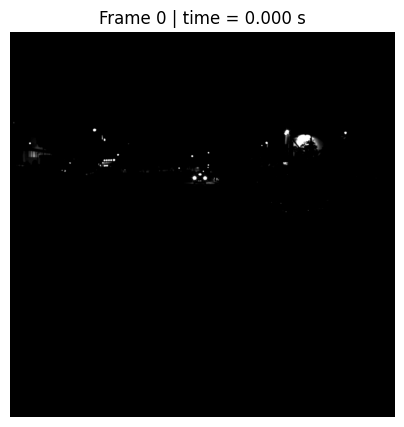

Frame 1 | time = 0.033 s | shape = (1280, 1280, 3)


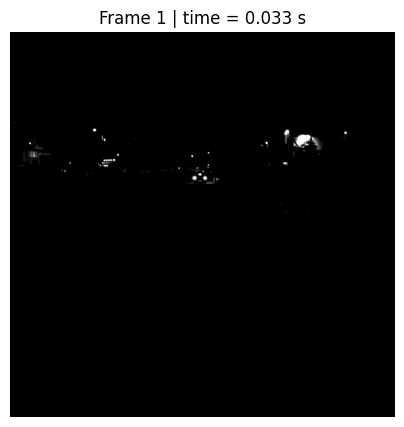

Frame 2 | time = 0.067 s | shape = (1280, 1280, 3)


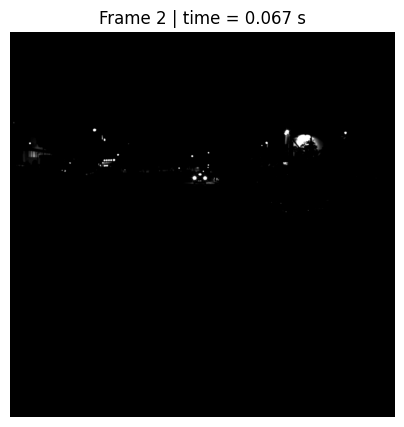

In [ ]:
import matplotlib.pyplot as plt

# distance_df'den bir clip_id seç (örnek: ilk satır)
example_clip_id = distance_df.iloc[30]["clip_id"]
print("Test clip_id:", example_clip_id)

for idx, t, frame in iterate_frames_for_clip(example_clip_id, source="distance", max_frames=3):
    print(f"Frame {idx} | time = {t:.3f} s | shape = {frame.shape}")

    # OpenCV BGR formatında verir, matplotlib için RGB'ye çevirelim
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(5, 5))
    plt.imshow(frame_rgb)
    plt.title(f"Frame {idx} | time = {t:.3f} s")
    plt.axis("off")
    plt.show()


In [ ]:
import numpy as np
import cv2

def to_gray(frame):
    """
    frame: OpenCV'nin okuduğu görüntü (BGR veya tek kanallı olabilir)
    çıktı: tek kanallı uint8 gri seviye görüntü
    """
    # Eğer zaten 2 boyutluysa (H, W) → zaten gri
    if frame.ndim == 2:
        gray = frame
    # 3 kanallı ise BGR'den griye çevir
    elif frame.ndim == 3 and frame.shape[2] == 3:
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    else:
        raise ValueError(f"Beklenmeyen frame şekli: {frame.shape}")

    # Tip kontrolü: uint8 değilse normalize edip uint8 yap
    if gray.dtype != np.uint8:
        gray = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    return gray


In [ ]:
def iterate_gray_frames_for_clip(clip_id: str, source: str = "distance", max_frames: int = None):
    """
    Verilen clip_id için:
      - orig_frame_idx
      - time_s
      - gray_frame (tek kanallı, uint8)
    üretir.
    """
    for orig_frame_idx, time_s, frame in iterate_frames_for_clip(clip_id, source=source, max_frames=max_frames):
        gray = to_gray(frame)
        yield orig_frame_idx, time_s, gray


Test clip_id: Arac1_75m_Basler acA2040-90umNIR (22821916)_20190513_211331999_Fren
Video açıldı: /Users/emreyigit/Desktop/sabanci/cs419/project/night_vehicle_raw/Mesafe - Exposure_50000_30fps/Arac1/75m/Basler acA2040-90umNIR (22821916)_20190513_211331999_Fren.mp4
Frame 0 | time = 0.000 s | shape = (1280, 1280) | dtype = uint8


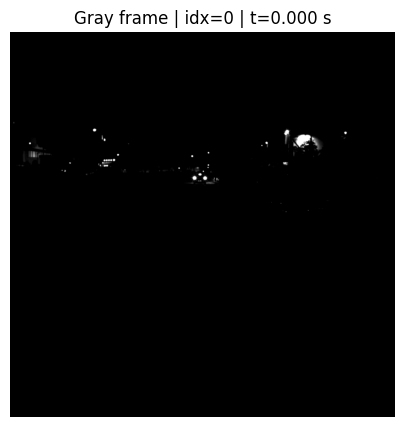

Frame 1 | time = 0.033 s | shape = (1280, 1280) | dtype = uint8


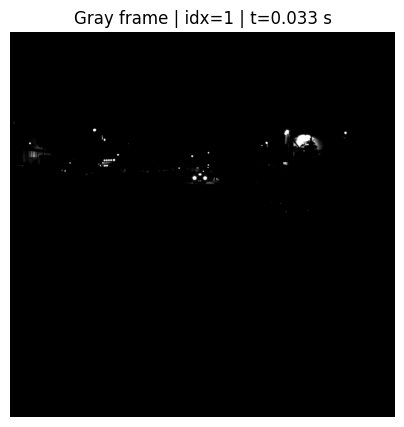

Frame 2 | time = 0.067 s | shape = (1280, 1280) | dtype = uint8


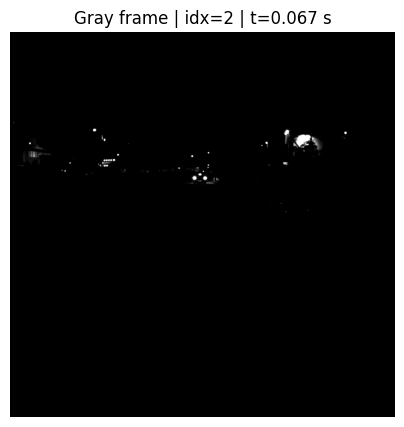

In [ ]:
import matplotlib.pyplot as plt

# distance_df'den bir örnek clip_id seç
example_clip_id = distance_df.iloc[30]["clip_id"]
print("Test clip_id:", example_clip_id)

for idx, t, gray in iterate_gray_frames_for_clip(example_clip_id,source="distance",max_frames=3):
    print(f"Frame {idx} | time = {t:.3f} s | shape = {gray.shape} | dtype = {gray.dtype}")

    # Gri frame'i görselleştir
    plt.figure(figsize=(5, 5))
    plt.imshow(gray, cmap="gray")
    plt.title(f"Gray frame | idx={idx} | t={t:.3f} s")
    plt.axis("off")
    plt.show()


In [ ]:
def apply_clahe(gray, clip_limit=2.0, tile_grid_size=(8, 8)):
    """
    gray: tek kanallı uint8 görüntü (H, W)
    clip_limit: kontrastın ne kadar artırılacağı (çok yükseltme, gürültüyü patlatabilir)
    tile_grid_size: CLAHE'in çalıştığı blokların boyutu

    çıktı: yine (H, W), uint8
    """
    if gray.ndim != 2:
        raise ValueError(f"CLAHE için beklenen şekil (H,W); aldığım: {gray.shape}")
    if gray.dtype != np.uint8:
        gray = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    enhanced = clahe.apply(gray)
    return enhanced

In [ ]:
def iterate_clahe_frames_for_clip(clip_id: str, source: str = "distance",
                                  max_frames: int = None,
                                  clip_limit: float = 2.0,
                                  tile_grid_size=(8, 8)):
    """
    Verilen clip_id için:
      - orig_frame_idx
      - time_s
      - clahe_frame (gri + CLAHE uygulanmış, uint8)
    üretir.
    """
    for orig_frame_idx, time_s, gray in iterate_gray_frames_for_clip(clip_id, source=source, max_frames=max_frames):

        clahe_frame = apply_clahe(gray, clip_limit=clip_limit,tile_grid_size=tile_grid_size)

        yield orig_frame_idx, time_s, clahe_frame


Test clip_id: Arac1_75m_Basler acA2040-90umNIR (22821916)_20190513_211331999_Fren
Video açıldı: /Users/emreyigit/Desktop/sabanci/cs419/project/night_vehicle_raw/Mesafe - Exposure_50000_30fps/Arac1/75m/Basler acA2040-90umNIR (22821916)_20190513_211331999_Fren.mp4
Frame 0 | time=0.000 s | shape=(1280, 1280) | dtype=uint8


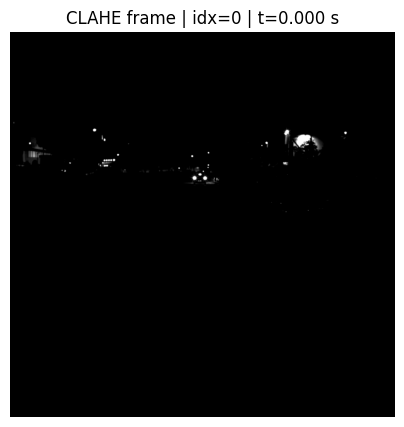

Frame 1 | time=0.033 s | shape=(1280, 1280) | dtype=uint8


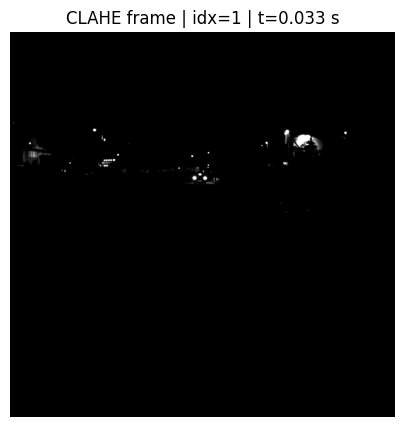

Frame 2 | time=0.067 s | shape=(1280, 1280) | dtype=uint8


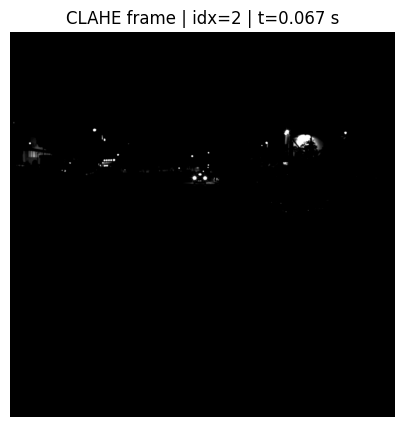

In [ ]:
import matplotlib.pyplot as plt

# Örnek bir distance clip_id seçelim
example_clip_id = distance_df.iloc[30]["clip_id"]
print("Test clip_id:", example_clip_id)

for idx, t, clahe_frame in iterate_clahe_frames_for_clip(
    example_clip_id,
    source="distance",
    max_frames=3
):
    print(f"Frame {idx} | time={t:.3f} s | shape={clahe_frame.shape} | dtype={clahe_frame.dtype}")

    # CLAHE uygulanmış gri frame'i görselleştir
    plt.figure(figsize=(5, 5))
    plt.imshow(clahe_frame, cmap="gray")
    plt.title(f"CLAHE frame | idx={idx} | t={t:.3f} s")
    plt.axis("off")
    plt.show()


In [ ]:
import cv2
import numpy as np

def apply_blur(gray, ksize: int = 3, sigma: float = 0.0):
    """
    gray: tek kanallı uint8 görüntü (CLAHE sonrası veya normal gri)
    ksize: kernel boyutu (tek sayı: 3, 5, 7...)
    sigma: Gaussian'ın sigma'sı (0 ise OpenCV otomatik seçer)

    Çok büyük kernel kullanma; 3 veya 5 yeterli.
    """
    if gray.ndim != 2:
        raise ValueError(f"Blur için beklenen şekil (H,W); aldığım: {gray.shape}")

    if ksize is None or ksize <= 1:
        # 1 veya daha küçükse blur uygulamaya gerek yok
        return gray

    # ksize tek sayı olmalı (3,5,7...)
    if ksize % 2 == 0:
        ksize += 1  # otomatik en yakın tek sayıya çekiyoruz

    blurred = cv2.GaussianBlur(gray, (ksize, ksize), sigma)
    return blurred


In [ ]:
def iterate_denoised_frames_for_clip(clip_id: str, source: str = "distance",
                                     max_frames: int = None,
                                     clip_limit: float = 2.0,
                                     tile_grid_size=(8, 8),
                                     blur_ksize: int = 3,
                                     blur_sigma: float = 0.0):
    """
    Verilen clip_id için:
      - orig_frame_idx
      - time_s
      - denoised_frame (Gray + CLAHE + Gaussian blur)
    üretir.

    Sıra:
      BGR frame -> gray -> CLAHE -> Gaussian blur
    """
    for orig_frame_idx, time_s, clahe_frame in iterate_clahe_frames_for_clip(
        clip_id,
        source=source,
        max_frames=max_frames,
        clip_limit=clip_limit,
        tile_grid_size=tile_grid_size
    ):
        denoised = apply_blur(clahe_frame, ksize=blur_ksize, sigma=blur_sigma)
        yield orig_frame_idx, time_s, denoised


Test clip_id: Arac1_75m_Basler acA2040-90umNIR (22821916)_20190513_211331999_Fren
Video açıldı: /Users/emreyigit/Desktop/sabanci/cs419/project/night_vehicle_raw/Mesafe - Exposure_50000_30fps/Arac1/75m/Basler acA2040-90umNIR (22821916)_20190513_211331999_Fren.mp4
Frame 0 | time=0.000 s | shape=(1280, 1280) | dtype=uint8


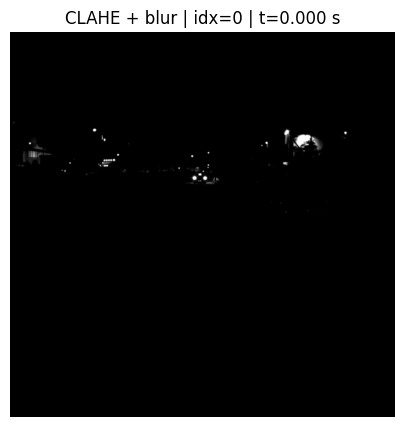

Frame 1 | time=0.033 s | shape=(1280, 1280) | dtype=uint8


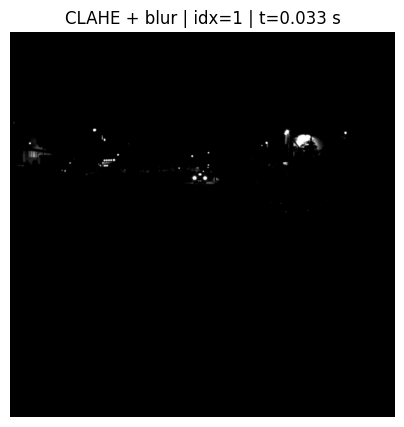

Frame 2 | time=0.067 s | shape=(1280, 1280) | dtype=uint8


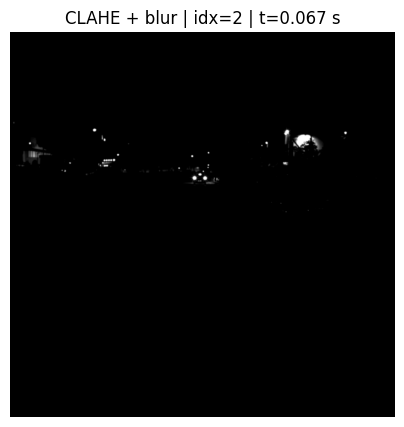

In [ ]:
import matplotlib.pyplot as plt

# Örnek bir distance clip_id
example_clip_id = distance_df.iloc[30]["clip_id"]
print("Test clip_id:", example_clip_id)

for idx, t, denoised in iterate_denoised_frames_for_clip(
    example_clip_id,
    source="distance",
    max_frames=3,
    clip_limit=2.0,
    tile_grid_size=(8, 8),
    blur_ksize=3,
    blur_sigma=0.0
):
    print(f"Frame {idx} | time={t:.3f} s | shape={denoised.shape} | dtype={denoised.dtype}")

    # CLAHE + blur uygulanmış frame'i görselleştir
    plt.figure(figsize=(5, 5))
    plt.imshow(denoised, cmap="gray")
    plt.title(f"CLAHE + blur | idx={idx} | t={t:.3f} s")
    plt.axis("off")
    plt.show()


EMRE PART

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

# --- KALMAN FILTER BASED TRACKER ---
class KalmanTracker:
    """Tek bir araç için Kalman Filter tabanlı tracker"""
    def __init__(self, bbox):
        # State: [x_center, y_center, width, height, vx, vy]
        self.kf = cv2.KalmanFilter(6, 4)

        # Transition matrix (A) - constant velocity model
        self.kf.transitionMatrix = np.array([
            [1, 0, 0, 0, 1, 0],  # x = x + vx
            [0, 1, 0, 0, 0, 1],  # y = y + vy
            [0, 0, 1, 0, 0, 0],  # w = w
            [0, 0, 0, 1, 0, 0],  # h = h
            [0, 0, 0, 0, 1, 0],  # vx = vx
            [0, 0, 0, 0, 0, 1]   # vy = vy
        ], dtype=np.float32)

        # Measurement matrix (H) - we observe [x, y, w, h]
        self.kf.measurementMatrix = np.array([
            [1, 0, 0, 0, 0, 0],
            [0, 1, 0, 0, 0, 0],
            [0, 0, 1, 0, 0, 0],
            [0, 0, 0, 1, 0, 0]
        ], dtype=np.float32)

        # Process noise covariance (Q)
        self.kf.processNoiseCov = np.eye(6, dtype=np.float32) * 0.1

        # Measurement noise covariance (R)
        self.kf.measurementNoiseCov = np.eye(4, dtype=np.float32) * 1.0

        # Error covariance matrix (P)
        self.kf.errorCovPost = np.eye(6, dtype=np.float32) * 100

        # Initialize state
        x, y, w, h = bbox
        cx, cy = x + w/2, y + h/2
        self.kf.statePre = np.array([cx, cy, w, h, 0, 0], dtype=np.float32)
        self.kf.statePost = np.array([cx, cy, w, h, 0, 0], dtype=np.float32)

        self.hits = 1
        self.time_since_update = 0

    def predict(self):
        """Tahmin adımı"""
        self.kf.predict()
        state = self.kf.statePost
        cx, cy, w, h = state[0], state[1], state[2], state[3]
        # Center'dan top-left corner'a çevir
        x = cx - w/2
        y = cy - h/2
        return [int(x), int(y), int(w), int(h)]

    def update(self, bbox):
        """Güncelleme adımı"""
        x, y, w, h = bbox
        cx, cy = x + w/2, y + h/2
        measurement = np.array([cx, cy, w, h], dtype=np.float32)
        self.kf.correct(measurement)
        self.hits += 1
        self.time_since_update = 0

    def get_state(self):
        """Mevcut durumu döndür"""
        state = self.kf.statePost
        cx, cy, w, h = state[0], state[1], state[2], state[3]
        x = cx - w/2
        y = cy - h/2
        return [int(x), int(y), int(w), int(h)]

class VehicleTracker:
    """Kalman Filter tabanlı çoklu araç tracker"""
    def __init__(self, distance_threshold=50, max_missing=5, min_hits=1):
        self.next_object_id = 0
        self.trackers = {}  # {id: KalmanTracker}
        self.distance_threshold = distance_threshold
        self.max_missing = max_missing
        self.min_hits = min_hits

    def update(self, detections):
        """Ana tracking fonksiyonu"""
        # 1. Tüm tracker'lar için tahmin yap
        predictions = {}
        for track_id, tracker in self.trackers.items():
            pred_bbox = tracker.predict()
            predictions[track_id] = pred_bbox
            tracker.time_since_update += 1

        # 2. Detection-prediction eşleştirme
        matched, unmatched_dets, unmatched_trks = self._associate_detections_to_trackers(
            detections, predictions)

        # 3. Eşleşen tracker'ları güncelle
        for det_idx, trk_id in matched:
            self.trackers[trk_id].update(detections[det_idx])

        # 4. Yeni detection'lar için tracker oluştur
        for det_idx in unmatched_dets:
            self._create_new_tracker(detections[det_idx])

        # 5. Kayıp tracker'ları temizle
        to_remove = []
        for track_id in unmatched_trks:
            if self.trackers[track_id].time_since_update > self.max_missing:
                to_remove.append(track_id)

        for track_id in to_remove:
            del self.trackers[track_id]

        # 6. Confirmed tracker'ları döndür
        return self._get_confirmed_tracks()

    def _associate_detections_to_trackers(self, detections, predictions):
        """Detection ve prediction'ları eşleştir"""
        if len(predictions) == 0:
            return [], list(range(len(detections))), []

        if len(detections) == 0:
            return [], [], list(predictions.keys())

        # Mesafe matrisi oluştur
        track_ids = list(predictions.keys())
        distance_matrix = np.zeros((len(detections), len(track_ids)))

        for i, det in enumerate(detections):
            for j, track_id in enumerate(track_ids):
                pred = predictions[track_id]
                distance_matrix[i, j] = self._calculate_distance(det, pred)

        # Hungarian algorithm yerine basit greedy matching
        matched = []
        unmatched_dets = list(range(len(detections)))
        unmatched_trks = list(range(len(track_ids)))

        # En yakın eşleştirmeleri bul
        while len(unmatched_dets) > 0 and len(unmatched_trks) > 0:
            # En küçük mesafeyi bul
            min_dist = float('inf')
            min_det_idx = -1
            min_trk_idx = -1

            for i in unmatched_dets:
                for j in unmatched_trks:
                    if distance_matrix[i, j] < min_dist:
                        min_dist = distance_matrix[i, j]
                        min_det_idx = i
                        min_trk_idx = j

            # Eşik kontrolü
            if min_dist < self.distance_threshold:
                matched.append((min_det_idx, track_ids[min_trk_idx]))
                unmatched_dets.remove(min_det_idx)
                unmatched_trks.remove(min_trk_idx)
            else:
                break

        # Kalan unmatched tracker ID'lerini döndür
        unmatched_trk_ids = [track_ids[i] for i in unmatched_trks]

        return matched, unmatched_dets, unmatched_trk_ids

    def _calculate_distance(self, det1, det2):
        """İki bbox arasındaki mesafeyi hesapla"""
        x1, y1, w1, h1 = det1
        x2, y2, w2, h2 = det2

        # Center point distance
        cx1, cy1 = x1 + w1/2, y1 + h1/2
        cx2, cy2 = x2 + w2/2, y2 + h2/2

        return math.sqrt((cx1 - cx2)**2 + (cy1 - cy2)**2)

    def _create_new_tracker(self, bbox):
        """Yeni tracker oluştur"""
        new_tracker = KalmanTracker(bbox)
        self.trackers[self.next_object_id] = new_tracker
        self.next_object_id += 1

    def _get_confirmed_tracks(self):
        """Confirmed tracker'ları döndür"""
        confirmed = []
        for track_id, tracker in self.trackers.items():
            if tracker.hits >= self.min_hits and tracker.time_since_update <= 1:
                bbox = tracker.get_state()
                confirmed.append((track_id, bbox))
        return confirmed

In [ ]:
def create_road_roi_mask(shape, y_start_ratio=0.375, y_end_ratio=0.6, x_start_ratio=0.2, x_end_ratio=0.6):
    h, w = shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)

    y1 = int(h * y_start_ratio); y2 = int(h * y_end_ratio)
    x1 = int(w * x_start_ratio); x2 = int(w * x_end_ratio)

    mask[y1:y2, x1:x2] = 255
    return mask

def apply_road_roi(img, roi_mask):
    return cv2.bitwise_and(img, img, mask=roi_mask)

def blob_features(cnt):
    area = cv2.contourArea(cnt)
    x, y, w, h = cv2.boundingRect(cnt)
    perim = cv2.arcLength(cnt, True)
    hull = cv2.convexHull(cnt)
    hull_area = cv2.contourArea(hull) + 1e-6

    aspect = w / (h + 1e-6)
    extent = area / (w * h + 1e-6)
    solidity = area / hull_area
    circularity = (4 * np.pi * area) / (perim * perim + 1e-6)

    cx = x + w / 2
    cy = y + h / 2

    return {
        "cnt": cnt, "x": x, "y": y, "w": w, "h": h, "cx": cx, "cy": cy,
        "area": area, "aspect": aspect, "extent": extent,
        "solidity": solidity, "circularity": circularity
    }

In [ ]:
def classify_distance_combined(y_bottom, vw):
    """
    Classifies distance using both Y-coordinate and Vehicle Width (vw).
    Scaled for 1280x1280 resolution (Original * 0.625).

    New Calibration Data (Approximate):
    25m:  Y~520, VW~124
    50m:  Y~494, VW~63
    75m:  Y~489, VW~39
    100m: Y~486, VW~32
    """

    # 1. Determine Distance based on Y (Vertical Perspective)
    # 811 * 0.625 = 506.8 -> 507
    if y_bottom > 507:
        y_score = 25
    # 786 * 0.625 = 491.2 -> 491
    elif y_bottom > 491:
        y_score = 50
    # 779 * 0.625 = 486.8 -> 487
    elif y_bottom > 487:
        y_score = 75
    else:
        y_score = 100

    # 2. Determine Distance based on VW (Scale/Width)
    # 149 * 0.625 = 93.1 -> 93
    if vw > 93:
        w_score = 25
    # 81 * 0.625 = 50.6 -> 51
    elif vw > 51:
        w_score = 50
    # 57 * 0.625 = 35.6 -> 36
    elif vw > 36:
        w_score = 75
    else:
        w_score = 100

    # 3. Fusion Logic: Average the two scores (Değişmedi)
    final_score = 0.75 * y_score + 0.25 * w_score

    # 4. Map to specific bins (Değişmedi)
    if final_score <= 25:
        return "<25m"
    elif 25 < final_score <= 50:
        return "25-50m"
    elif 50 < final_score <= 75:
        return "50-75m"
    elif 75 < final_score <= 100:
        return "75-100m"
    else:
        return ">100m"

In [ ]:
def preprocess_frame(denoised):
    """Handles thresholding, ROI masking, and morphological cleaning."""
    _, binary = cv2.threshold(denoised, 235, 255, cv2.THRESH_BINARY)
    roi_mask = None

    # (1) roi_mask'i threshold'dan ÖNCE üretmemiz gerekiyor
    if roi_mask is None:
        roi_mask = create_road_roi_mask(
            denoised.shape,          # binary.shape yerine denoised.shape
            y_start_ratio=0.375,
            y_end_ratio=1,
            x_start_ratio=0,
            x_end_ratio=1
        )


    binary_roi = apply_road_roi(binary, roi_mask)

    # Noise Reduction & Closing gaps
    kernel_noise = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    kernel_horizontal = cv2.getStructuringElement(cv2.MORPH_RECT, (8, 2))

    binary_roi = cv2.morphologyEx(binary_roi, cv2.MORPH_OPEN, kernel_noise)
    binary_roi = cv2.morphologyEx(binary_roi, cv2.MORPH_CLOSE, kernel_horizontal)

    return binary_roi

def get_candidate_blobs(binary_img):
    """Extracts contours and filters them based on geometric properties."""
    contours, _ = cv2.findContours(binary_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    candidates = []

    for cnt in contours:
        f = blob_features(cnt)
        # Geometry filters
        if not (5 < f["area"] < 30000): continue
        if not (0.3 < f["aspect"] < 4.0): continue
        if not (0.15 < f["extent"] < 1.0): continue
        if f["w"] > f["h"] * 5: continue
        candidates.append(f)

    return sorted(candidates, key=lambda f: f["cx"])

def find_vehicle_pairs(candidates, frame_height):
    """Logic to pair light blobs into single vehicle bounding boxes."""
    possible_pairs = []

    for i in range(len(candidates)):
        for j in range(i + 1, len(candidates)):
            a, b = candidates[i], candidates[j]
            avg_y = (a["cy"] + b["cy"]) / 2.0
            closeness = avg_y / frame_height

            # Dynamic Parameters
            width_multiplier = 0.2 + (closeness * 0.6)
            max_allowed_dx = avg_y * width_multiplier
            min_allowed_dx = avg_y * 0.02
            max_allowed_dy = avg_y * 0.1

            dx = abs(a["cx"] - b["cx"])
            dy = abs(a["cy"] - b["cy"])
            avg_light_width = (a["w"] + b["w"]) / 2.0

            # Constraints
            gap_limit = 12.0 if closeness > 0.8 else 8.0
            area_limit = 5.0 if closeness > 0.8 else 3.0

            if dx > avg_light_width * gap_limit: continue
            if dy > max_allowed_dy: continue
            if not (min_allowed_dx < dx < max_allowed_dx): continue

            area_ratio = max(a["area"], b["area"]) / (min(a["area"], b["area"]) + 1e-6)
            if area_ratio > area_limit: continue

            # Heuristic score (lower is better)
            score = dy + (area_ratio * 5) + (dx * 0.01)
            possible_pairs.append((score, i, j))

    # Resolve overlapping pairs
    possible_pairs.sort(key=lambda x: x[0])
    final_boxes = []
    used = set()

    for _, i, j in possible_pairs:
        if i in used or j in used: continue

        a, b = candidates[i], candidates[j]
        vx = min(a["x"], b["x"])
        vy = min(a["y"], b["y"])
        vw = max(a["x"] + a["w"], b["x"] + b["w"]) - vx
        vh = max(a["y"] + a["h"], b["y"] + b["h"]) - vy

        final_boxes.append((vx, vy, vw, vh))
        used.update([i, j])

    return final_boxes

def filter_reflections(boxes):
    """Removes boxes that appear to be vertical reflections (e.g., on wet pavement)."""
    boxes.sort(key=lambda b: b[1]) # Sort by Y (top to bottom)
    filtered = []

    for box_a in boxes:
        is_reflection = False
        center_ax = box_a[0] + box_a[2] / 2

        for box_b in filtered:
            center_bx = box_b[0] + box_b[2] / 2
            # If horizontally aligned and lower in the frame, it's likely a reflection
            if abs(center_ax - center_bx) < 30 and box_a[1] > box_b[1]:
                is_reflection = True
                break

        if not is_reflection:
            filtered.append(box_a)
    return filtered

In [ ]:
def visualize_tracks(image, tracked_objects, fps=0, elapsed_time_s=0, window_name="Vehicle Detection"):
    """
    Draws boxes and IDs onto the frame using cv2.imshow (more efficient).

    Args:
        image: Gri seviye veya BGR görüntü
        tracked_objects: [(id, (x,y,w,h)), ...] listesi
        window_name: OpenCV pencere adı
    """
    # Eğer gri ise BGR'ye çevir
    if image.ndim == 2:
        output_img = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    else:
        output_img = image.copy()

    # Kutuları ve bilgileri çiz
    for obj_id, (x, y, w, h) in tracked_objects:
        y_bottom = y + h
        dist_bin = classify_distance_combined(y_bottom, w)

        # Renk seçimi
        if dist_bin == "<25m":
            color = (0, 0, 255)  # Kırmızı (tehlikeli!)
        elif dist_bin == "25-50m":
            color = (0, 165, 255)  # Turuncu (uyarı)
        else:
            color = (0, 255, 0)  # Yeşil (güvenli)

        # Kutu çiz
        cv2.rectangle(output_img, (x, y), (x + w, y + h), color, 2)

        # ID ve mesafe etiketi
        label = f"ID:{obj_id} | {dist_bin}"
        cv2.putText(output_img, label, (x, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
        # Bilgi paneli oluştur (sol üst)
    info_y = 30
    cv2.putText(output_img, f"FPS: {fps:.0f}", (10, info_y),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
    cv2.putText(output_img, f"Time: {elapsed_time_s:.1f}s", (10, info_y + 30),  # ← GÜNCEL
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
    cv2.putText(output_img, f"Vehicles: {len(tracked_objects)}", (10, info_y + 60),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
    # cv2.imshow ile göster
    cv2.imshow(window_name, output_img)

    return output_img

In [ ]:
def run_vehicle_pair_detection(example_clip_id, max_frames=None, frame_skip=1, show_display=True):
    """
    Video üzerinde araç tespiti ve izleme çalıştır.

    Args:
        example_clip_id: Clip ID (distance veya exposure)
        max_frames: Maksimum frame sayısı (None = tüm video)
        frame_skip: Her kaç frame'de bir işle (performans için)
        show_display: cv2.imshow göster (False = sadece işle, pencere açma)
    """
    import time

    print(f"Processing: {example_clip_id}")
    print("Durdur: Q veya Control + C tuşu")
    print("-" * 60)

    # Kalman Filter için optimize edilmiş parametreler
    tracker = VehicleTracker(distance_threshold=50, max_missing=5, min_hits=1)
    frame_count = 0
    processed_count = 0
    start_time = time.time()

    try:
        for idx, t, denoised in iterate_denoised_frames_for_clip(
            example_clip_id,
            source="exposure",
            max_frames=max_frames
        ):
            frame_count += 1

            # Frame skip (performans iyileştirmesi)
            if frame_count % frame_skip != 0:
                continue

            processed_count += 1
            frame_start_time = time.time()
            # 1. Image Processing
            binary_roi = preprocess_frame(denoised)

            # 2. Candidate Extraction
            candidates = get_candidate_blobs(binary_roi)

            # 3. Pairing
            raw_vehicles = find_vehicle_pairs(candidates, binary_roi.shape[0])

            # 4. Reflection Filtering
            clean_vehicles = filter_reflections(raw_vehicles)

            # 5. Kalman Filter Tracking
            tracked_objects = tracker.update(clean_vehicles)
            elapsed = time.time() - start_time
            fps = processed_count / elapsed if elapsed > 0 else 0
            # 6. Visualization (cv2.imshow)
            if show_display:
                output = visualize_tracks(denoised, tracked_objects, fps=fps, elapsed_time_s=elapsed, window_name="Kalman Filter Vehicle Tracking")
                # ESC veya Q tuşu ile çıkış (waitKey 1ms)
                key = cv2.waitKey(1) & 0xFF
                if key == 27 or key == ord('q'):  # ESC veya Q
                    print("\n>>> Kullanıcı tarafından durduruldu")
                    break

            # Status bilgisi
            if processed_count % 5 == 0:  # Her 5. process'te yazdır (daha hızlı)
                elapsed = time.time() - start_time
                fps = processed_count / elapsed if elapsed > 0 else 0
                print(f"Frame {frame_count:4d} | Processed: {processed_count:3d} | "
                      f"Detected: {len(raw_vehicles):2d} | Tracked: {len(tracked_objects):2d} | "
                      f"Time: {t:.2f}s | FPS: {fps:.1f}")

        elapsed = time.time() - start_time
        print(f"\n{'='*60}")
        print(f"✓ Tamamlandı!")
        print(f"  Toplam frame: {frame_count}")
        print(f"  İşlenen frame: {processed_count}")
        print(f"  Süre: {elapsed:.2f}s")
        if elapsed > 0:
            print(f"  Ortalama FPS: {processed_count/elapsed:.1f}")
        print(f"{'='*60}")

    except KeyboardInterrupt:
        print("\n>>> CTRL+C tarafından durduruldu")
    except Exception as e:
        print(f"\n>>> HATA: {e}")
        import traceback
        traceback.print_exc()
    finally:
        # Güvenli kapatma
        cv2.destroyAllWindows()
        print("Windows kapatıldı.")

In [ ]:
print(f"Toplam clip: {len(exposure_df)}")
print(f"\nYol tipleri:")
print(exposure_df['road_type'].value_counts())
print(f"\nİlk 3 clip:")
for i in range(min(3, len(exposure_df))):
    row = exposure_df.iloc[i]
    print(f"  {i+1}. {row['clip_id']}")
    print(f"     Yol: {row['road_type']} | Duration: {row['duration_s']:.1f}s")

# Test çalıştır
print(f"\n{'='*60}")
print("KALMAN FILTER VIDEO TESTI BAŞLIYOR")
print("İyileştirmeler:")
print("- Constant velocity motion model")
print("- Prediction-correction cycle")
print("- Daha stabil tracking")
print(f"{'='*80}\n")

example_clip_id = exposure_df.iloc[0]["clip_id"]
print(f"Clip: {example_clip_id}\n")

# Başla - Kalman Filter ile optimized parametreler
run_vehicle_pair_detection(
    example_clip_id,
    max_frames=None,      # Tüm frames
    frame_skip=1,         # Her 2. frame göster
    show_display=True     # Kalman Filter tracking'i göster
)

Toplam clip: 28

Yol tipleri:
road_type
3lane_median           13
2lane_bidirectional    11
2lane_median            4
Name: count, dtype: int64

İlk 3 clip:
  1. YolTip1_Basler acA2040-90umNIR (22821916)_20190509_213729558
     Yol: 3lane_median | Duration: 60.7s
  2. YolTip1_Basler acA2040-90umNIR (22821916)_20190509_213419972
     Yol: 3lane_median | Duration: 60.7s
  3. YolTip1_Basler acA2040-90umNIR (22821916)_20190509_213209731
     Yol: 3lane_median | Duration: 60.7s

KALMAN FILTER VIDEO TESTI BAŞLIYOR
İyileştirmeler:
- Constant velocity motion model
- Prediction-correction cycle
- Daha stabil tracking

Clip: YolTip1_Basler acA2040-90umNIR (22821916)_20190509_213729558

Processing: YolTip1_Basler acA2040-90umNIR (22821916)_20190509_213729558
Durdur: Q veya Control + C tuşu
------------------------------------------------------------
Video açıldı: /Users/emreyigit/Desktop/sabanci/cs419/project/night_vehicle_raw/Exposure_50000_30fps/Yol Tip1/Basler acA2040-90umNIR (22821916)_201905

In [ ]:
# ===== RESET & CLEANUP HÜCRESİ =====
# Eğer video donmuş ise bu hücreyi çalıştır
import cv2
import gc

print("OpenCV windows kapatılıyor...")
cv2.destroyAllWindows()

print("Garbage collection...")
gc.collect()

print("✓ Sistem temizlendi. Tekrar çalıştırabilirsin.")

OpenCV windows kapatılıyor...
Garbage collection...
✓ Sistem temizlendi. Tekrar çalıştırabilirsin.
